# Statistische procesbeheersing van laagdikte over productielijnen met PROC BOXPLOT

## Managementsamenvatting

Dit notebook gebruikt **PROC BOXPLOT** om statistische procesbeheersing (SPC) uit te voeren op een voor de kwaliteit kritische meting van laagdikte, verzameld over vier parallelle productielijnen. We genereren synthetische meetgegevens inline, profileren de lijnen met `PROC MEANS`, en tekenen skeletachtige en schematische boxplots die locatie, spreiding en staarten over de lijnen op één grafiek vergelijken.

Vervolgens beoordelen we elke lijn ten opzichte van de technische specificatie (streefwaarde 50,00 mm, grenzen 49,80–50,20 mm) rechtstreeks vanuit de **`OUTBOX=`** statistiekdataset — de exacte kwartielen, hekken en snorhaareindpunten achter elke box — en tot slot demonstreren we het **`OUTHISTORY=` / `HISTORY=`** rondgang-patroon: PROC BOXPLOT exporteert één compacte samenvattingsrij per lijn, en een tweede PROC BOXPLOT reconstrueert een identieke grafiek rechtstreeks uit die samenvatting, het patroon dat een dagelijks SPC-dashboard gebruikt om opnieuw te plotten zonder de ruwe metingen opnieuw te doorlopen.

Over de vier lijnen heen is **LINE-A het best gecentreerd** op de streefwaarde (gemiddelde 50,008 mm), **loopt LINE-C laag** (gemiddelde 49,932 mm, drijvend richting de LSL), en **loopt LINE-D zowel hoog als het meest variabel** (gemiddelde 50,102 mm, std 0,080 mm) — het maximum van 50,248 mm is de enige waarneming die de bovengrens van 50,20 mm overschrijdt.

## Gegevensbronnen

Alle gegevens zijn synthetisch en worden inline gegenereerd door de eerste DATA-stap met `call streaminit(20250531)` en `rand()`. Er wordt geen externe of netwerkinvoer gebruikt. De vaste seed maakt elk getal in dit notebook reproduceerbaar.

**Dataset: `ProcessMeas`** (één rij per gemeten onderdeel)

| Variabele | Type | Beschrijving |
|----------|------|-------------|
| `Line` | Char(6) | Identificatie van de productielijn: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (de groeps-/classificatievariabele) |
| `Shift` | Num | Index van de productieploeg 1–6 (introduceert milde drift tussen ploegen) |
| `Thickness` | Num | Laagdikte in mm (de analysevariabele); streefwaarde 50,00 mm, specificatiegrenzen 49,80–50,20 mm |

Elke lijn is gecentreerd rond een iets ander gemiddelde (50,00 / 50,04 / 49,92 / 50,10) met lijnspecifieke variatie, wat werkelijke verschillen tussen apparaten nabootst, en `LINE-B` injecteert af en toe een kleine positieve uitschieter. De DATA-stap doorloopt zes ploegen en vier lijnen met subgroepgroottes van ongeveer 18–25 onderdelen elk; in deze omgeving zonder licentie begrenst de engine de uitvoer tot de eerste **100 waarnemingen**, wat hier neerkomt op **38 / 19 / 21 / 22** onderdelen voor LINE-A tot en met LINE-D — nog steeds ruim voldoende om vier goed gedefinieerde boxen te vullen.

# Statistische procesbeheersing van laagdikte met PROC BOXPLOT

In productie met hoge volumes is een boxplot het werkpaard van SPC op de werkvloer: het vat de centrale tendens, spreiding en uitschieters van een kwaliteitskenmerk voor elke productie-eenheid samen op één grafiek. Hier bewaken we **laagdikte (mm)** op een onderdeel dat parallel op vier lijnen wordt geproduceerd (`LINE-A` tot en met `LINE-D`). De technische specificatie is een streefwaarde van **50,00 mm** met een ondergrens (LSL) van **49,80 mm** en een bovengrens (USL) van **50,20 mm**.

We gaan:

1. Inline een synthetische meetdataset genereren.
2. De lijnen profileren met `PROC MEANS`.
3. Een eenvoudige skeletachtige boxplot tekenen, daarna een schematische plot, met de specificatiegrenzen als referentielijnen eroverheen.
4. Elke berekende boxstatistiek vastleggen met `OUTBOX=` en elke lijn ten opzichte van de specificatiegrenzen beoordelen op basis van die tabel.
5. Een compacte subgroepsamenvatting bewaren met `OUTHISTORY=` en de rondgang bewijzen door rechtstreeks daaruit opnieuw te plotten met `HISTORY=`.

## Stap 1 — Genereer synthetische procesmetingen

De DATA-stap hieronder simuleert metingen over zes ploegen op vier lijnen. Elke lijn is bewust gecentreerd rond een iets ander gemiddelde met zijn eigen variatie, wat werkelijke verschillen tussen apparaten nabootst, en een milde drift tussen ploegen wordt toegevoegd met een `sin(Shift)`-term. Een vaste seed (`streaminit(20250531)`) maakt elke waarde in het notebook reproduceerbaar.

In [1]:
GEGEVENS ProcessMeas;
   CALL streaminit(20250531);
   LENGTE Line $6;
   REEKS lines[4] $6 _temporary_ ('LIJN-A' 'LIJN-B' 'LIJN-C' 'LIJN-D');
   REEKS lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   REEKS lsd[4]     _temporary_ (0.045 0.060 0.050 0.085);
   label Thickness='Laagdikte (mm)' Line='Productielijn';
   DOE Shift = 1 TOT 6;
      DOE li = 1 TOT 4;
         Line = lines[li];
         /* wisselende subgroepgrootte per lijn/ploeg */
         n = 18 + floor(rand('uniform') * 8);
         DOE u = 1 TOT n;
            base = lmean[li] + 0.012 * sin(Shift);
            Thickness = base + rand('normal') * lsd[li];
            /* LIJN-B introduceert af en toe hoge uitschieters */
            ALS li = 2 and rand('uniform') < 0.05 DAN
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            UITVOER;
         EINDE;
      EINDE;
   EINDE;
   VERWIJDEREN li u n base;
UITVOEREN;



NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Stap 2 — Profileer de lijnen

Voordat we plotten, bevestigt een snelle `PROC MEANS` dat de gegevens zijn aangekomen zoals bedoeld: vier lijnen, bescheiden maar niet-triviale steekproefgroottes, en gemiddelden geclusterd nabij de streefwaarde van 50,00 mm met lijnspecifieke spreiding. Dit is de numerieke ruggengraat die de boxplot zal visualiseren.

In [2]:
PROCEDURE GEMIDDELDEN GEGEVENS=ProcessMeas n mean std MIN MAX maxdec=3;
   KLASSE Line;
   VARIABELE Thickness;
   label Line='Productielijn' Thickness='Laagdikte (mm)';
   TITEL 'Samenvatting laagdikte per productielijn';
UITVOEREN;


                                        Samenvatting laagdikte per productielijn                                        

                                                  The MEANS Procedure

                                      Analysis Variable : Thickness Laagdikte (mm)

        Productielijn          N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        LIJN-A                    38         50.008          0.045         49.914         50.097
        LIJN-B                    19         50.052          0.051         49.921         50.114
        LIJN-C                    21         49.932          0.050         49.835         50.002
        LIJN-D                    22         50.102          0.080         49.963         50.248
        ----------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 3 — Eenvoudige skeletachtige boxplot

De eenvoudigste aanroep vereist alleen de instructie `PLOT analysevariabele * groepsvariabele`. De standaard `BOXSTYLE=SKELETAL` tekent snorharen naar de meest extreme waarnemingen binnen elke lijn, wat een snelle visuele vergelijking geeft van locatie en spreiding over `LINE-A` tot en met `LINE-D`.

                                          Skeletboxplot van laagdikte per lijn                                          

                                          Skeletboxplot van laagdikte per lijn

                                                 The BOXPLOT Procedure

Skeletal Plots for Laagdikte (mm)

Productielijn         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LIJN-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LIJN-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LIJN-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LIJN-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-------


NOTE: Option TITLE changed to Skeletboxplot van laagdikte per lijn.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


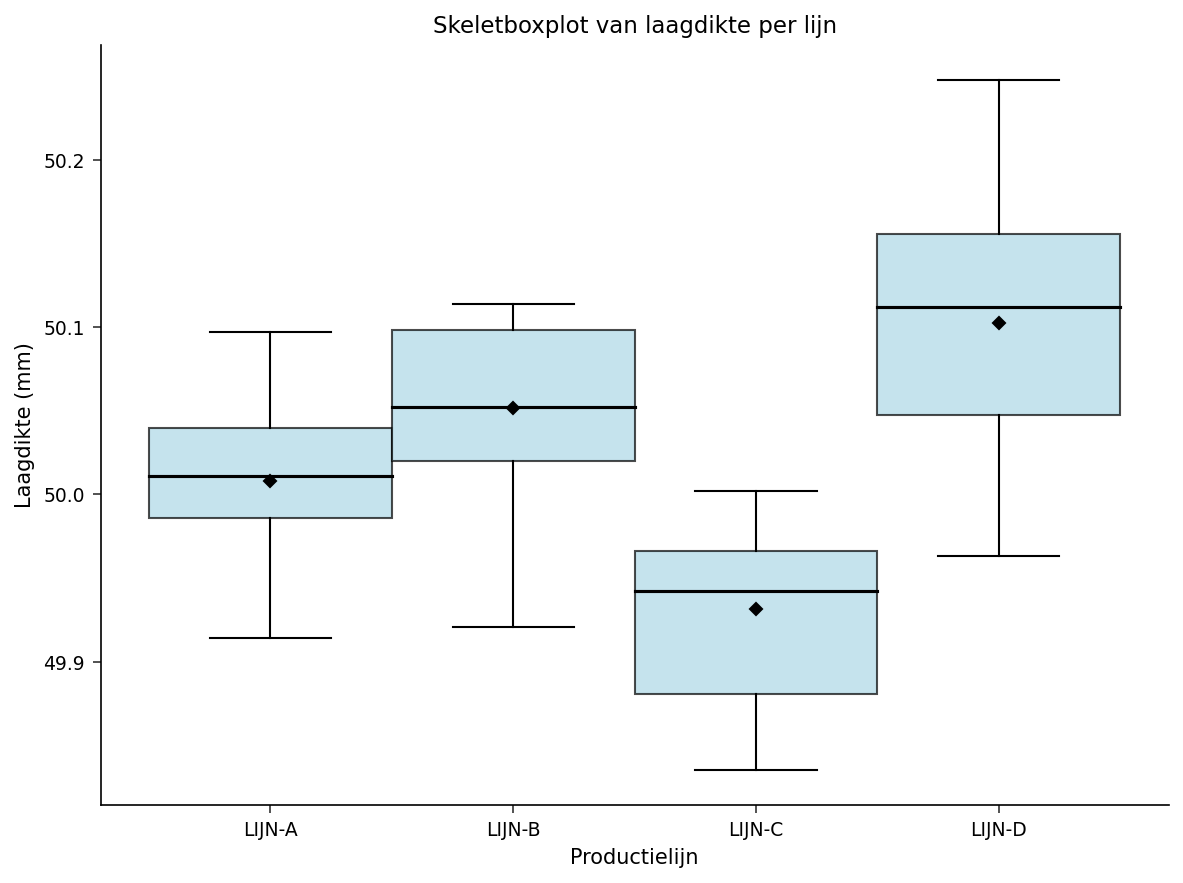

In [3]:
TITEL 'Skeletboxplot van laagdikte per lijn';
PROCEDURE boxplot GEGEVENS=ProcessMeas;
   PLOT Thickness*Line;
   label Thickness='Laagdikte (mm)' Line='Productielijn';
UITVOEREN;


## Stap 4 — Schematische boxplot

We schakelen over naar `BOXSTYLE=SCHEMATIC`. In schematische stijl wordt elke snorhaar afgekapt bij de meest extreme waarneming die nog binnen de 1,5 × IQR-hekken valt, en elk punt voorbij een hek wordt getekend als een individuele uitschietermarkering. In deze steekproef heeft geen enkele lijn een uitschieter voorbij het hek — de spreiding van elke lijn is compact genoeg dat de snorharen het werkelijke minimum en maximum bereiken — dus de schematische grafiek lijkt op de skeletachtige, wat zelf een nuttig resultaat is: het vertelt de ingenieur dat geen van de vier lijnen extreme onderdelen produceert. De boxlichamen maken de verschuivingen tussen lijnen nog steeds in één oogopslag duidelijk, en Stap 5 kwantificeert ze ten opzichte van de specificatiegrenzen.

                                    SPC schematische boxplot van laagdikte per lijn                                     

                                    SPC schematische boxplot van laagdikte per lijn

                                                 The BOXPLOT Procedure

Schematic Plots for Laagdikte (mm)

Productielijn         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LIJN-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LIJN-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LIJN-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LIJN-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
-


NOTE: Option TITLE changed to SPC schematische boxplot van laagdikte per lijn.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


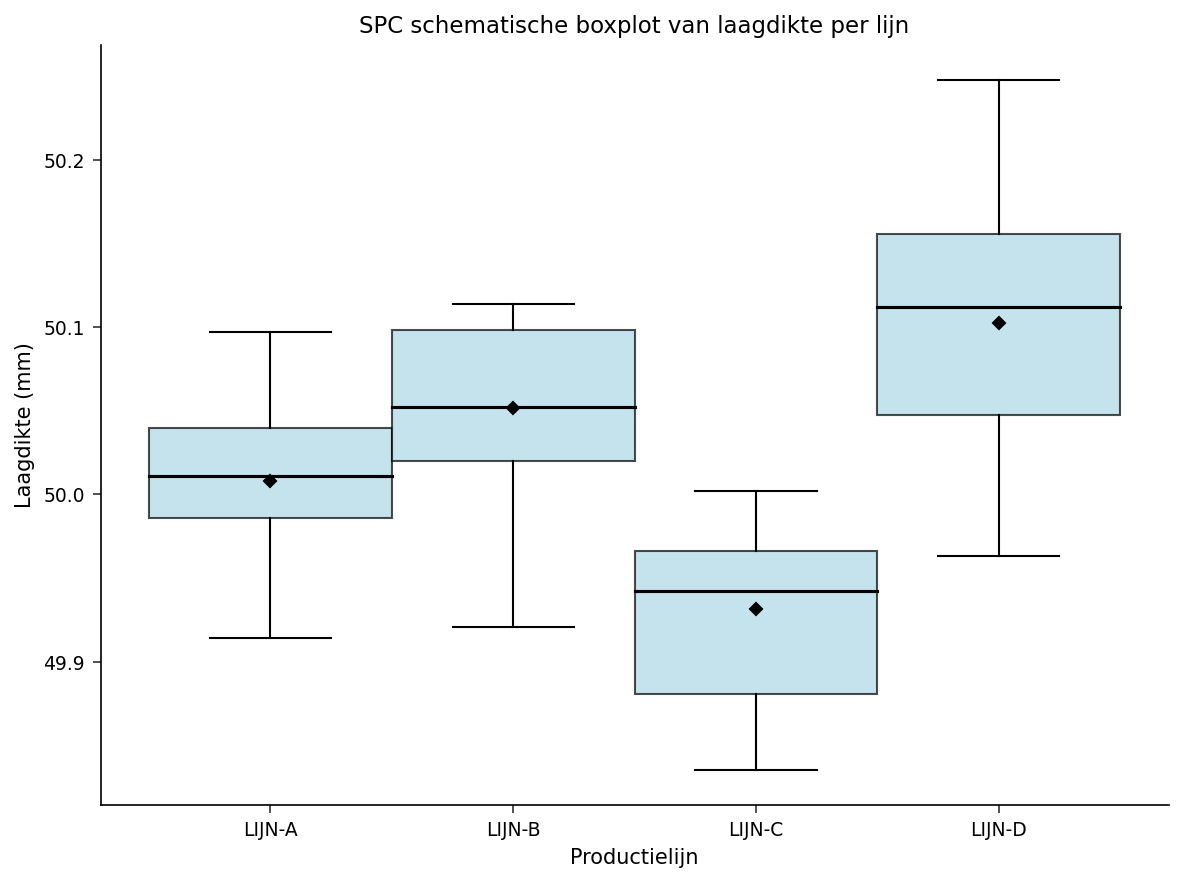

In [4]:
TITEL 'SPC schematische boxplot van laagdikte per lijn';
PROCEDURE boxplot GEGEVENS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
   label Thickness='Laagdikte (mm)' Line='Productielijn';
UITVOEREN;


## Stap 5 — Exporteer boxstatistieken en beoordeel ten opzichte van de specificatiegrenzen

De optie `OUTBOX=` legt elke berekende boxstatistiek vast in een dataset — voor elke lijn: de lage snorhaar (`L`), Q1 (`1`), gemiddelde (`X`), mediaan (`M`), Q3 (`3`), hoge snorhaar (`H`), standaarddeviatie (`S`) en N. Dit is de numerieke registratie die een auditor nodig heeft achter het beeld, en het is ook de schoonste manier om elke lijn te controleren ten opzichte van de specificatie van 49,80 / 50,20 mm. We schakelen `GRID` in voor betere leesbaarheid, exporteren `BoxStats`, printen het, en voeren dan een korte DATA-stap uit die elke lijn markeert waarvan het snorharenbereik voorbij een specificatiegrens komt.

                                  Schematische boxplot met raster en statistiekexport                                   

                                  Schematische boxplot met raster en statistiekexport

                                                 The BOXPLOT Procedure

Schematic Plots for Laagdikte (mm)

Productielijn         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LIJN-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LIJN-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LIJN-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LIJN-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08


NOTE: Option TITLE changed to Schematische boxplot met raster en statistiekexport.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Berekende boxstatistieken (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Beoordeling t.o.v. specificatiegrenzen per lijn.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


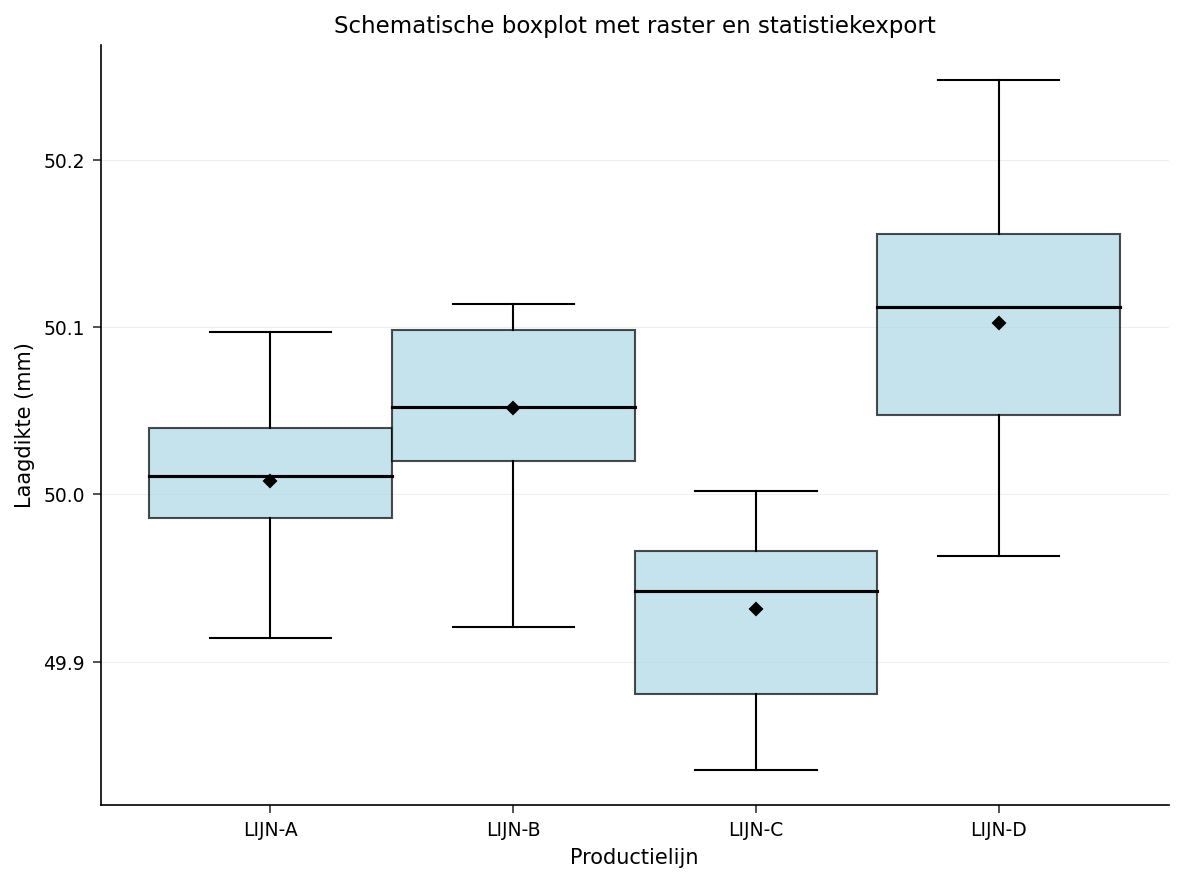

In [5]:
TITEL 'Schematische boxplot met raster en statistiekexport';
PROCEDURE boxplot GEGEVENS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
   label Thickness='Laagdikte (mm)' Line='Productielijn';
UITVOEREN;

TITEL 'Berekende boxstatistieken (OUTBOX=)';
PROCEDURE AFDRUKKEN GEGEVENS=BoxStats noobs;
UITVOEREN;

/* Beoordeel elke lijn ten opzichte van de specificatie 49.80 / 50.20 mm */
/* met behulp van de geexporteerde snorhaareindpunten (THICKNESSL = onderste */
/* snorhaar, THICKNESSH = bovenste snorhaar).                                */
GEGEVENS SpecCheck;
   SET BoxStats;
   LENGTE Status $40;
   LSL = 49.80;
   USL = 50.20;
   ALS THICKNESSH > USL DAN Status = 'Hoge waarden boven USL';
   ANDERS ALS THICKNESSL < LSL DAN Status = 'Lage waarden onder LSL';
   ANDERS Status = 'Binnen specificatie';
   BEWAREN LINE THICKNESSL THICKNESSH LSL USL Status;
UITVOEREN;

TITEL 'Beoordeling t.o.v. specificatiegrenzen per lijn';
PROCEDURE AFDRUKKEN GEGEVENS=SpecCheck noobs label;
   label LINE='Productielijn' THICKNESSL='Onderste snorhaar'
         THICKNESSH='Bovenste snorhaar' LSL='Ondergrens (LSL)'
         USL='Bovengrens (USL)' Status='Status';
UITVOEREN;


## Stap 6 — Bewaar een bewakingsgeschiedenis en plot er opnieuw uit

Bij doorlopende SPC doorloop je zelden elke ruwe meting opnieuw. `OUTHISTORY=` schrijft één samenvattingsrij per lijn (dezelfde indeling die `HISTORY=` verbruikt), zodat de zware ruwe gegevens gearchiveerd kunnen worden. Hieronder exporteren we `LineHistory`, printen het, en bewijzen dan de rondgang door het rechtstreeks terug te voeren in een nieuwe `PROC BOXPLOT` via `HISTORY=` — precies zoals een dagelijks dashboard vooraf geaggregeerde subgroepstatistieken zou hergebruiken.

                                            Subgroepgeschiedenis exporteren                                             

                                            Subgroepgeschiedenis exporteren

                                                 The BOXPLOT Procedure

Skeletal Plots for Laagdikte (mm)

Productielijn         N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LIJN-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LIJN-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LIJN-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LIJN-D               22        49.96        50.05        50.11        50.16        50.25        50.10         0.08
----------


NOTE: Option TITLE changed to Subgroepgeschiedenis exporteren.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Samenvattende geschiedenisdataset (een rij per lijn).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Boxplot gereconstrueerd uit samenvattende geschiedenis.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


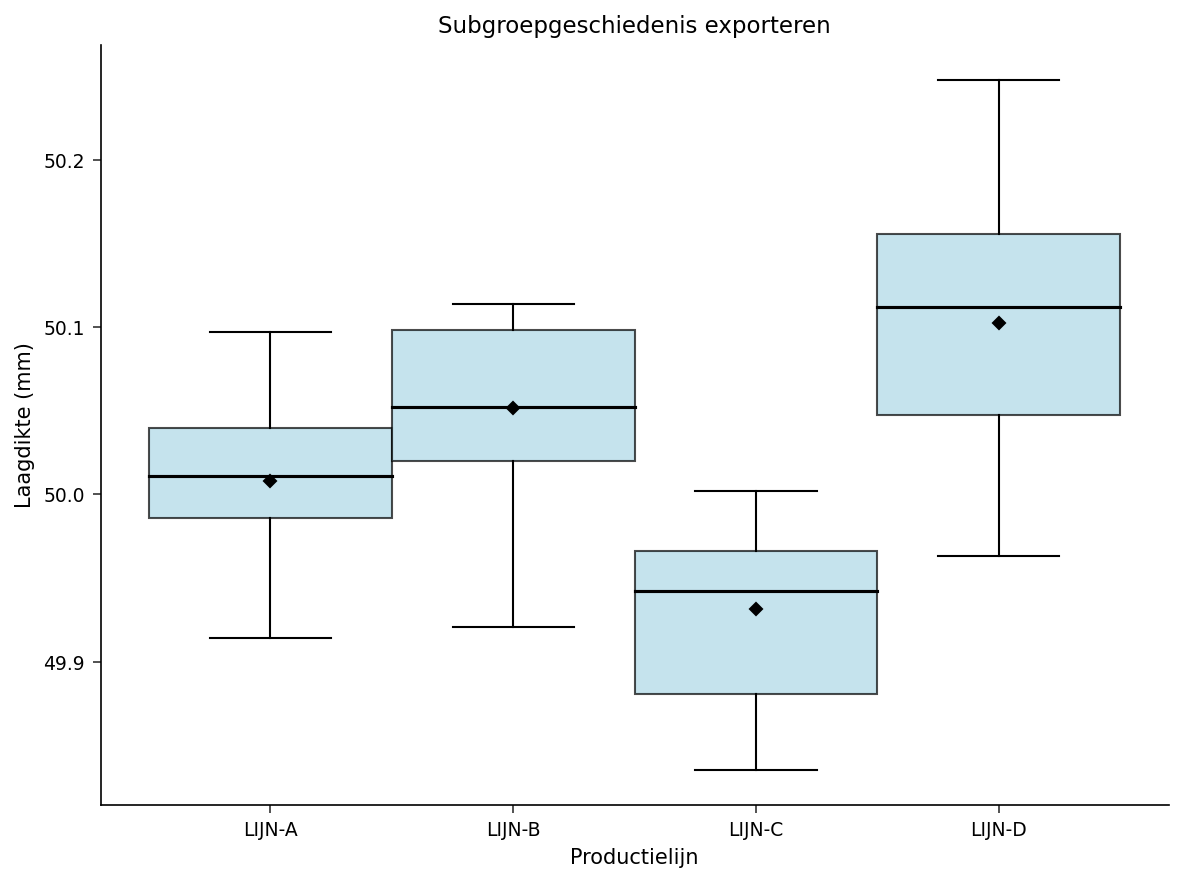

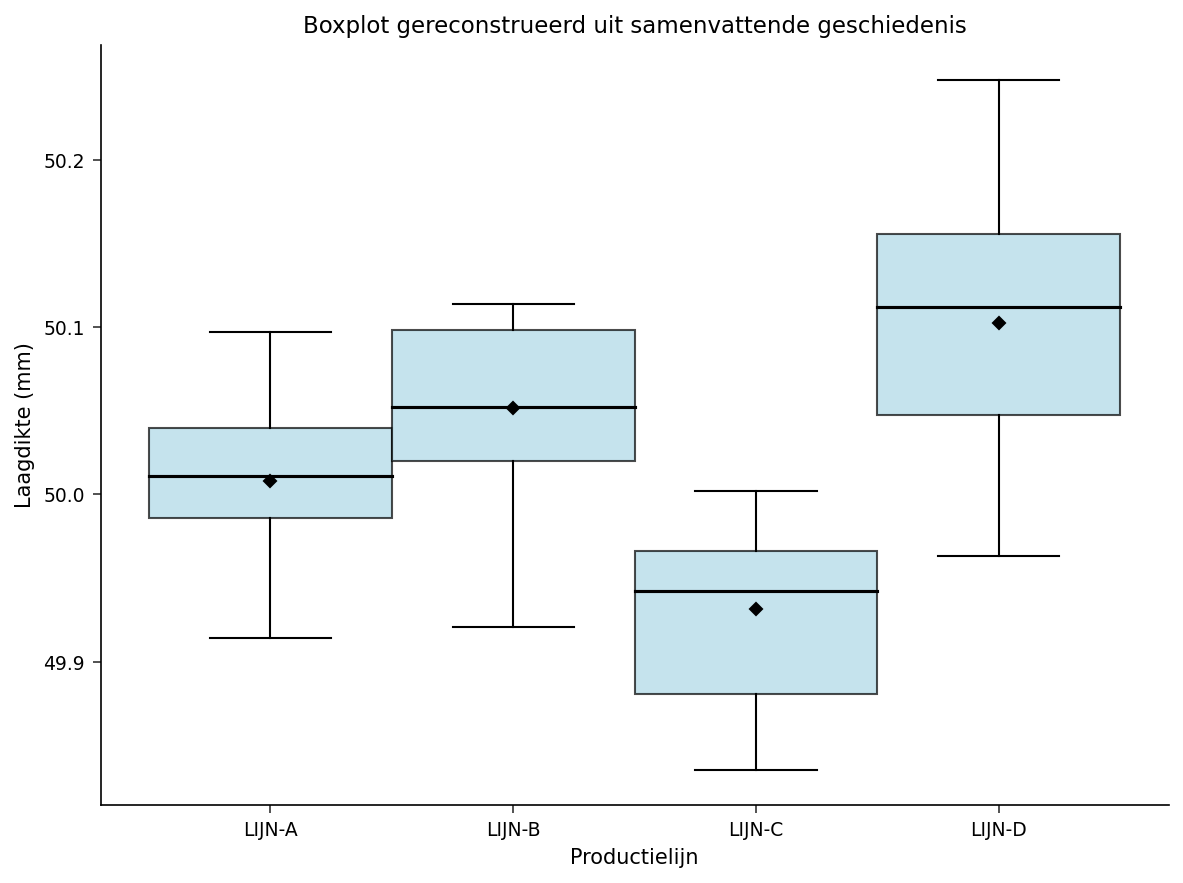

In [6]:
TITEL 'Subgroepgeschiedenis exporteren';
PROCEDURE boxplot GEGEVENS=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
   label Thickness='Laagdikte (mm)' Line='Productielijn';
UITVOEREN;

TITEL 'Samenvattende geschiedenisdataset (een rij per lijn)';
PROCEDURE AFDRUKKEN GEGEVENS=LineHistory noobs;
UITVOEREN;

TITEL 'Boxplot gereconstrueerd uit samenvattende geschiedenis';
PROCEDURE boxplot history=LineHistory;
   PLOT Thickness*Line;
   label Thickness='Laagdikte (mm)' Line='Productielijn';
UITVOEREN;


## De resultaten interpreteren

Door de boxplots samen te lezen met het `PROC MEANS`-profiel, de `OUTBOX=`-tabel en de beoordeling van de specificatiegrenzen:

- **Centrering.** `LINE-A` is het best gecentreerd op de streefwaarde van 50,00 mm (gemiddelde 50,008 mm, mediaan 50,011 mm). `LINE-B` loopt iets hoog (gemiddelde 50,052 mm). `LINE-C` loopt laag (gemiddelde 49,932 mm, mediaan 49,942 mm), de lijn drijft richting de LSL. `LINE-D` loopt hoog (gemiddelde 50,102 mm, mediaan 50,112 mm), de lijn die het dichtst bij de USL ligt.
- **Spreiding.** `LINE-D` toont de breedste box en de langste snorharen — de standaarddeviatie van 0,080 mm is ongeveer 60–80% groter dan die van de andere drie lijnen (0,045–0,051 mm), wat het markeert als de minst stabiele lijn en de beste kandidaat voor een studie naar variatiereductie. `LINE-A` is de strakste (std 0,045 mm).
- **Staarten.** In schematische stijl produceert geen enkele lijn een uitschieter voorbij het hek: elke snorhaar bereikt het werkelijke minimum/maximum van zijn lijn, dus het proces produceert geen geïsoleerde extreme onderdelen. De verschillen in spreiding worden gedreven door het merendeel van elke verdeling, niet door losse punten.
- **Conformiteit met de specificatie.** De snorhaareindpunten uit `OUTBOX=`, beoordeeld ten opzichte van 49,80 / 50,20 mm, plaatsen `LINE-A`, `LINE-B` en `LINE-C` volledig **binnen de specificatie**. `LINE-D` is de uitzondering: de hoge snorhaar bereikt **50,248 mm**, voorbij de **USL van 50,20 mm** — hoge onderdelen op `LINE-D` overschrijden de bovenste specificatie.
- **Operationalisering.** De `OUTBOX=`-dataset geeft auditors de exacte kwartielen, snorhaareindpunten, gemiddelde en standaarddeviatie achter het beeld, en `OUTHISTORY=` levert een compacte, opnieuw te plotten samenvatting van één rij per lijn (Stap 6) zodat de grafiek volgens een schema kan worden gegenereerd zonder de ruwe metingen te bewaren — de boxplot die uit de samenvatting is gereconstrueerd is identiek aan die welke uit de ruwe gegevens is getekend.

**Actiepunten:** geef prioriteit aan `LINE-D` — centreer hem opnieuw naar beneden richting de streefwaarde én start een studie naar variatiereductie om zijn hoge snorhaar terug binnen de USL te trekken; duw `LINE-C` omhoog richting de streefwaarde voordat zijn lage staart de LSL bereikt; `LINE-A` en `LINE-B` presteren acceptabel.